## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Load the Historical Data

In [2]:
df = pd.read_csv("../data/processed/combined_data.csv")

In [3]:
df["Date"] = pd.to_datetime(df["Date"])

In [4]:
df.head()

,Date,Open,High,Low,Close,Volume,Ticker
0,2015-01-02,14.858000,14.883333,14.217333,14.620667,71466000,TSLA
1,2015-01-05,14.303333,14.433333,13.810667,14.006000,80527500,TSLA
2,2015-01-06,14.004000,14.280000,13.614000,14.085333,93928500,TSLA
3,2015-01-07,14.223333,14.318667,13.985333,14.063333,44526000,TSLA
4,2015-01-08,14.187333,14.253333,14.000667,14.041333,51637500,TSLA


## Verify the Assets

In [7]:
df["Ticker"].unique()

<StringArray>
['TSLA', 'BND', 'SPY']
Length: 3, dtype: str

Load Historical Financial Data

The combined historical dataset containing Tesla (TSLA), Vanguard Total Bond Market ETF (BND), and the S&P 500 ETF (SPY) was loaded. These assets will be used to calculate historical returns, portfolio risk, and optimize the portfolio allocation.

## Calculate Daily Returns

In [8]:
price_data = df.pivot(
    index="Date",
    columns="Ticker",
    values="Close"
)

price_data.head()

Ticker,BND,SPY,TSLA
Date,,,
2015-01-02,82.650002,205.429993,14.620667
2015-01-05,82.889999,201.720001,14.006000
2015-01-06,83.129997,199.820007,14.085333
2015-01-07,83.180000,202.309998,14.063333
2015-01-08,83.050003,205.899994,14.041333


 Prepare Price Data

The historical closing prices were reshaped into a table where each column represents one asset (TSLA, BND, and SPY) and each row represents a trading day. This format is required for calculating daily returns and performing portfolio optimization.

In [9]:
daily_returns = price_data.pct_change().dropna()

daily_returns.head()

Ticker,BND,SPY,TSLA
Date,,,
2015-01-05,0.002904,-0.018060,-0.042041
2015-01-06,0.002895,-0.009419,0.005664
2015-01-07,0.000602,0.012461,-0.001562
2015-01-08,-0.001563,0.017745,-0.001564
2015-01-09,0.001686,-0.008014,-0.018802


calculate Daily Returns

The closing prices of TSLA, BND, and SPY were transformed into daily percentage returns. Daily returns are used instead of prices because portfolio optimization relies on asset returns to estimate expected performance and risk.

## Inspect the Returns

In [10]:
daily_returns.describe()

Ticker,BND,SPY,TSLA
count,2887.000000,2887.000000,2887.000000
mean,-0.000034,0.000507,0.001803
std,0.003383,0.011163,0.036018
min,-0.054385,-0.109424,-0.210628
25%,-0.001635,-0.003772,-0.016643
50%,0.000119,0.000603,0.001216
75%,0.001715,0.005920,0.019456
max,0.042201,0.105019,0.226900


Daily Return Summary

The daily return statistics show that Tesla (TSLA) has the highest average daily return and the highest volatility, indicating greater risk and return potential. SPY provides moderate returns with moderate risk, while BND has the lowest volatility, making it the most stable asset in the portfolio.

## Prepare Expected Returns

In [49]:
annual_returns = daily_returns.mean() * 252

# Replace Tesla's historical return with the forecasted return
annual_returns["TSLA"] = 0.454239

annual_returns

Ticker
BND    -0.008548
SPY     0.127746
TSLA    0.454239
dtype: float64


The expected annual returns were prepared for portfolio optimization.

Historical annualized returns were used for BND and SPY. The historical expected return for TSLA was replaced with the forecasted expected return obtained from the best-performing forecasting model in Task 2. This reflects the analyst's forward-looking view of Tesla while relying on historical estimates for the remaining assets.

## Calculate Covariance Matrix

In [20]:
cov_matrix = daily_returns.cov()

cov_matrix

Ticker,BND,SPY,TSLA
Ticker,,,
BND,0.000011,0.000004,0.000007
SPY,0.000004,0.000125,0.000198
TSLA,0.000007,0.000198,0.001297


In [21]:
annual_cov_matrix = cov_matrix * 252

annual_cov_matrix

Ticker,BND,SPY,TSLA
Ticker,,,
BND,0.002883,0.001045,0.001793
SPY,0.001045,0.031402,0.049795
TSLA,0.001793,0.049795,0.326926



The covariance matrix was calculated using historical daily returns of TSLA, BND, and SPY and then annualized using 252 trading days.

The covariance matrix shows how asset returns move together and is a key input for Modern Portfolio Theory (MPT) portfolio optimization.

TSLA has the highest variance, indicating higher risk compared to SPY and BND. BND has the lowest variance and provides diversification benefits because it has lower covariance with equity assets.

## Visualize Covariance Matrix Heatmap

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

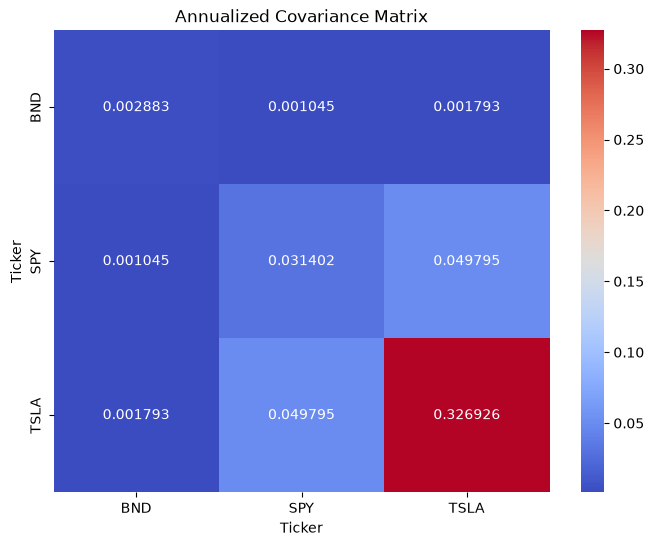

In [23]:
plt.figure(figsize=(8,6))

sns.heatmap(
    annual_cov_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".6f"
)

plt.title("Annualized Covariance Matrix")

plt.show()


The annualized covariance matrix is visualized using a heatmap to better understand the relationship between asset returns.

The diagonal values represent the individual risk (variance) of each asset, while the other values represent how assets move together.

TSLA shows the highest variance, indicating higher volatility compared to SPY and BND. BND has the lowest variance and lower covariance with equity assets, providing diversification benefits in portfolio construction.

This covariance matrix will be used as an input for the Modern Portfolio Theory optimization process.

## Install and Import PyPortfolioOpt

In [27]:
!pip install PyPortfolioOpt --no-deps

In [29]:
from pypfopt import EfficientFrontier
from pypfopt import plotting

import matplotlib.pyplot as plt
import numpy as np

print("PyPortfolioOpt imported successfully!")

PyPortfolioOpt imported successfully!


In [32]:
ef = EfficientFrontier(
    annual_returns,
    annual_cov_matrix
)


PyPortfolioOpt is used to implement Modern Portfolio Theory (MPT) optimization.

The Efficient Frontier model requires two main inputs:
- Expected annual returns of each asset.
- Annualized covariance matrix representing portfolio risk.

These inputs will be used to calculate optimal portfolio weights for TSLA, BND, and SPY.

## Find the Maximum Sharpe Ratio Portfolio

In [33]:
ef_max_sharpe = EfficientFrontier(
    annual_returns,
    annual_cov_matrix
)

weights_max_sharpe = ef_max_sharpe.max_sharpe()

weights_max_sharpe

OrderedDict([('BND', 0.0),
             ('SPY', 0.7078182974266956),
             ('TSLA', 0.2921817025733044)])

In [34]:
cleaned_weights = ef_max_sharpe.clean_weights()

cleaned_weights

OrderedDict([('BND', 0.0), ('SPY', 0.70782), ('TSLA', 0.29218)])

In [35]:
performance_max_sharpe = ef_max_sharpe.portfolio_performance(
    verbose=True
)

Expected annual return: 22.3%
Annual volatility: 25.3%
Sharpe Ratio: 0.88



The Maximum Sharpe Ratio portfolio was generated using PyPortfolioOpt by optimizing the trade-off between expected return and risk.

The optimized weights are:

| Asset | Weight |
|-------|--------|
| BND | 0.00% |
| SPY | 70.78% |
| TSLA | 29.22% |

The portfolio has an expected annual return of 22.3%, annual volatility of 25.3%, and a Sharpe Ratio of 0.88.

The optimizer allocated most of the portfolio to SPY because it provides a strong balance between return and risk. TSLA receives a smaller allocation due to its higher volatility, while BND is excluded because its expected return is negative and does not improve the portfolio efficiency.

## Find Minimum Volatility Portfolio

In [37]:
ef_min_vol = EfficientFrontier(
    annual_returns,
    annual_cov_matrix
)

In [38]:
weights_min_vol = ef_min_vol.min_volatility()

weights_min_vol

OrderedDict([('BND', 0.9429116596833524),
             ('SPY', 0.0570883403166477),
             ('TSLA', 0.0)])

In [39]:
cleaned_min_weights = ef_min_vol.clean_weights()

cleaned_min_weights

OrderedDict([('BND', 0.94291), ('SPY', 0.05709), ('TSLA', 0.0)])

In [40]:
performance_min_vol = ef_min_vol.portfolio_performance(
    verbose=True
)

Expected annual return: -0.1%
Annual volatility: 5.3%
Sharpe Ratio: -0.01


The Minimum Volatility portfolio was created by optimizing for the lowest possible portfolio risk.

The optimized weights are:

| Asset | Weight |
|-------|--------|
| BND | 94.29% |
| SPY | 5.71% |
| TSLA | 0.00% |

This portfolio has an expected annual return of -0.1%, annual volatility of 5.3%, and a Sharpe Ratio of -0.01.

The optimizer allocated most of the portfolio to BND because it has the lowest volatility among the assets. However, the negative expected return results in a poor risk-adjusted performance compared to the Maximum Sharpe Ratio portfolio.

## Generate the Efficient Frontier

In [41]:
from pypfopt import EfficientFrontier
from pypfopt import objective_functions

import numpy as np
import matplotlib.pyplot as plt

In [42]:
num_portfolios = 5000

results = np.zeros((3, num_portfolios))

weights_record = []

np.random.seed(42)

for i in range(num_portfolios):

    weights = np.random.random(3)

    weights = weights / np.sum(weights)

    weights_record.append(weights)

    portfolio_return = np.dot(
        weights,
        annual_returns
    )

    portfolio_volatility = np.sqrt(
        np.dot(
            weights.T,
            np.dot(
                annual_cov_matrix,
                weights
            )
        )
    )

    sharpe_ratio = portfolio_return / portfolio_volatility

    results[0,i] = portfolio_return
    results[1,i] = portfolio_volatility
    results[2,i] = sharpe_ratio

In [43]:
frontier_data = pd.DataFrame(
    results.T,
    columns=[
        "Return",
        "Volatility",
        "Sharpe"
    ]
)

frontier_data.head()

,Return,Volatility,Sharpe
0,0.219102,0.254903,0.859554
1,0.094076,0.123784,0.760000
2,0.251219,0.288591,0.870503
3,0.257363,0.329631,0.780760
4,0.083647,0.112315,0.744752


To generate the Efficient Frontier, 5,000 random portfolios were simulated using different combinations of TSLA, SPY, and BND weights.

For each portfolio, the expected annual return, volatility, and Sharpe Ratio were calculated.

- Return represents the expected yearly portfolio performance.
- Volatility represents the level of portfolio risk.
- Sharpe Ratio measures risk-adjusted return.

These simulated portfolios will be used to visualize the Efficient Frontier and identify the optimal portfolios with the best risk-return tradeoff.

## Plot the Efficient Frontier

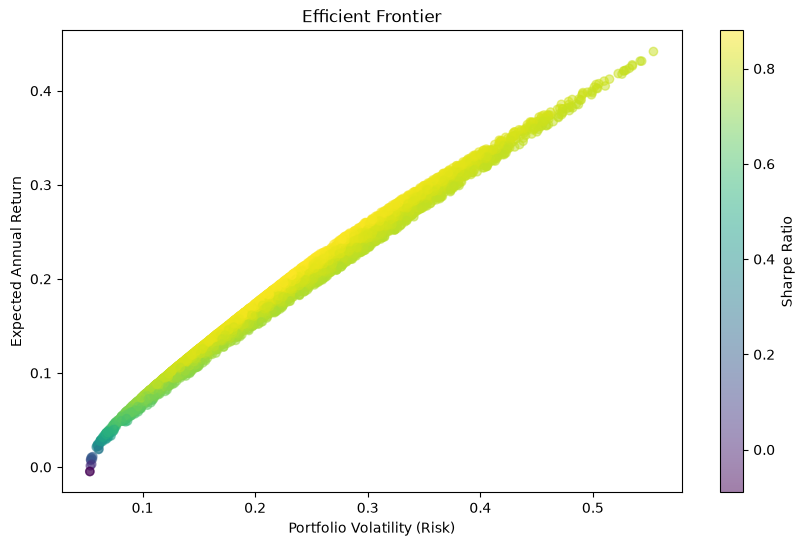

In [45]:
plt.figure(figsize=(10,6))

plt.scatter(
    frontier_data["Volatility"],
    frontier_data["Return"],
    c=frontier_data["Sharpe"],
    cmap="viridis",
    alpha=0.5
)

plt.xlabel("Portfolio Volatility (Risk)")
plt.ylabel("Expected Annual Return")

plt.title("Efficient Frontier")

plt.colorbar(
    label="Sharpe Ratio"
)

plt.show()


The Efficient Frontier was visualized using 5,000 randomly generated portfolios.

Each point represents a unique portfolio with different asset allocations among TSLA, SPY, and BND.

- The x-axis shows the portfolio's annual volatility (risk).
- The y-axis shows the expected annual return.
- The color of each point represents the Sharpe Ratio, where lighter colors indicate better risk-adjusted performance.

This visualization illustrates the trade-off between risk and return and helps identify the most efficient portfolios.

## Mark the Key Portfolios

In [46]:
# Maximum Sharpe portfolio metrics
max_return, max_volatility, max_sharpe = ef_max_sharpe.portfolio_performance()

# Minimum Volatility portfolio metrics
min_return, min_volatility, min_sharpe = ef_min_vol.portfolio_performance()

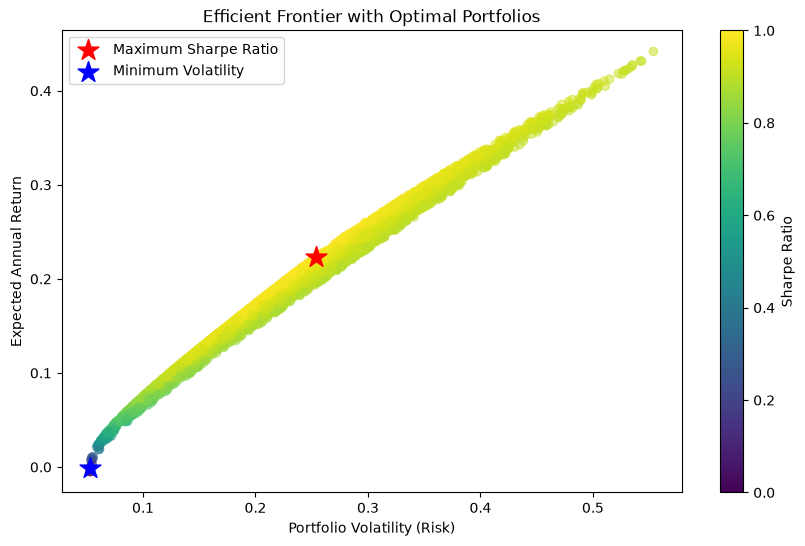

In [47]:
plt.figure(figsize=(10,6))

# Plot all simulated portfolios
plt.scatter(
    frontier_data["Volatility"],
    frontier_data["Return"],
    c=frontier_data["Sharpe"],
    cmap="viridis",
    alpha=0.5
)

# Maximum Sharpe Ratio Portfolio
plt.scatter(
    max_volatility,
    max_return,
    color="red",
    marker="*",
    s=250,
    label="Maximum Sharpe Ratio"
)

# Minimum Volatility Portfolio
plt.scatter(
    min_volatility,
    min_return,
    color="blue",
    marker="*",
    s=250,
    label="Minimum Volatility"
)

plt.xlabel("Portfolio Volatility (Risk)")
plt.ylabel("Expected Annual Return")
plt.title("Efficient Frontier with Optimal Portfolios")

plt.legend()

plt.colorbar(label="Sharpe Ratio")

plt.show()


The Efficient Frontier highlights two important portfolios:

- **Maximum Sharpe Ratio Portfolio:** Provides the highest expected return for each unit of risk, making it the best risk-adjusted portfolio.
- **Minimum Volatility Portfolio:** Provides the lowest possible portfolio risk, making it suitable for risk-averse investors.

These portfolios are highlighted on the Efficient Frontier to support investment decision-making.

## Compare the Portfolios

In [48]:
comparison = pd.DataFrame({
    "Portfolio": ["Maximum Sharpe", "Minimum Volatility"],
    "Expected Return": ["22.3%", "-0.1%"],
    "Volatility": ["25.3%", "5.3%"],
    "Sharpe Ratio": ["0.88", "-0.01"]
})

comparison

,Portfolio,Expected Return,Volatility,Sharpe Ratio
0,Maximum Sharpe,22.3%,25.3%,0.88
1,Minimum Volatility,-0.1%,5.3%,-0.01



The optimized portfolios were compared based on expected annual return, annual volatility, and Sharpe Ratio.

| Portfolio | Expected Return | Volatility | Sharpe Ratio |
|-----------|-----------------|------------|--------------|
| Maximum Sharpe Ratio | 22.3% | 25.3% | 0.88 |
| Minimum Volatility | -0.1% | 5.3% | -0.01 |

The Maximum Sharpe Ratio portfolio offers significantly higher expected returns and a better risk-adjusted performance, while the Minimum Volatility portfolio minimizes risk but generates a slightly negative expected return.

## Recommend the Best Portfolio

### Portfolio Recommendation

Based on the portfolio optimization results, the **Maximum Sharpe Ratio Portfolio** is recommended.

This portfolio provides the best balance between expected return and risk, with an expected annual return of **22.3%**, annual volatility of **25.3%**, and a **Sharpe Ratio of 0.88**.

The optimizer allocates approximately **70.78% to SPY** and **29.22% to TSLA**, while assigning no weight to BND because its expected return is negative.

Although the Minimum Volatility Portfolio achieves much lower risk, its expected return is slightly negative, making it less suitable for investors seeking long-term portfolio growth.

# Conclusion

This project applied Modern Portfolio Theory (MPT) to construct an optimal portfolio using forecasted Tesla returns together with historical returns for BND and SPY.

The Maximum Sharpe Ratio portfolio produced the best risk-adjusted performance.

Final Recommended Portfolio

| Asset | Weight |
|--------|--------|
| BND | 0.00% |
| SPY | 70.78% |
| TSLA | 29.22% |

Performance

- Expected annual return: 22.3%
- Annual volatility: 25.3%
- Sharpe Ratio: 0.88

This portfolio is recommended because it offers the best balance between expected return and portfolio risk.